In [19]:
import pandas as pd
import numpy as np

In [20]:
sentences = pd.read_csv('../data/sentences_with_metadata_order_3ormore.csv')
len(sentences)

1537279

In [21]:
num_none_speakers = sentences['speaker'].isna().sum()
percentage_none_speakers = (num_none_speakers / len(sentences)) * 100
print(f"Number of rows with speaker = None: {num_none_speakers}")
print(f"Percentage of rows with speaker = None: {percentage_none_speakers:.2f}%")

Number of rows with speaker = None: 302732
Percentage of rows with speaker = None: 19.69%


In [22]:
episode_details = pd.read_csv('../data/episodes_with_id.csv')
with open('../data/good_episode_ids.txt', 'r') as file:
    good_episode_ids = file.read().splitlines()
episode_details['episode_id'] = episode_details['episode_id'].astype(str)
good_episode_ids = [str(eid) for eid in good_episode_ids]
rj_episodes = episode_details[episode_details['episode_id'].isin(good_episode_ids)]
len(rj_episodes)

6365

In [23]:
multi_rj_episodes = rj_episodes[rj_episodes['totalSpLabels'] != 1]
len(multi_rj_episodes)

3593

In [24]:
sentences['episode_id'] = sentences['episode_id'].astype(int)
multi_rj_episodes.loc[:, 'episode_id'] = multi_rj_episodes['episode_id'].astype(int)
filtered_sentences = sentences[sentences['episode_id'].isin(multi_rj_episodes['episode_id'])]
len(filtered_sentences)

1069454

In [25]:
speaker_counts = filtered_sentences['newSpeaker'].value_counts()
print(speaker_counts)

newSpeaker
SPEAKER_01    348455
SPEAKER_00    337781
SPEAKER_02     69918
SPEAKER_03     19163
SPEAKER_04      7287
SPEAKER_05      2099
SPEAKER_06       551
SPEAKER_08        61
SPEAKER_07        51
SPEAKER_09        46
Name: count, dtype: int64


In [26]:
num_none_speakers = filtered_sentences['speaker'].isna().sum()
percentage_none_speakers = (num_none_speakers / len(filtered_sentences)) * 100
print(f"Number of rows with speaker = None: {num_none_speakers}")
print(f"Percentage of rows with speaker = None: {percentage_none_speakers:.2f}%")

Number of rows with speaker = None: 284042
Percentage of rows with speaker = None: 26.56%


In [27]:
filtered_sentences = filtered_sentences.drop(columns=['time'])

In [28]:
filtered_sentences = filtered_sentences.reset_index(drop=True)

In [29]:
filtered_sentences.loc[filtered_sentences['racialJustice'] != 1, 'racialJustice'] = 0

In [30]:
filtered_sentences.loc[~((filtered_sentences['racialJustice'] == 1) & (filtered_sentences['collectiveAction'] == 0)), 'collectiveActionMulti'] = np.nan

### Assign metadata to n, NaN, n

In [31]:
for i in range(1, len(filtered_sentences) - 1): 
    try:
        if pd.isna(filtered_sentences.loc[i, 'speaker']):  # Check if 'speaker' is NaN
            prev_row = filtered_sentences.loc[i - 1]  # Previous row
            next_row = filtered_sentences.loc[i + 1]  # Next row
            
            if (prev_row['episode_id'] == next_row['episode_id'] and
                prev_row['speaker'] == next_row['speaker'] and
                prev_row['newSpeaker'] == next_row['newSpeaker'] and
                prev_row['turnCount'] == next_row['turnCount']):
            
                # Assign the metadata from the previous row to the current row
                columns_to_copy = [
                    'speaker', 'newSpeaker', 'mfcc1_sma3Mean', 'mfcc2_sma3Mean', 
                    'mfcc3_sma3Mean', 'mfcc4_sma3Mean', 'F0semitoneFrom27_5Hz_sma3nzMean', 
                    'F1frequency_sma3nzMean', 'startTime', 'endTime', 'duration', 'turnCount'
                ]
                
                for column in columns_to_copy:
                    filtered_sentences.loc[i, column] = prev_row[column]

    except KeyError:  # Handle case where the index does not exist
        #print(f"Skipping index {i} due to missing value.")
        continue  # Continue to the next iteration

In [32]:
num_none_speakers = filtered_sentences['speaker'].isna().sum()
percentage_none_speakers = (num_none_speakers / len(filtered_sentences)) * 100
print(f"Number of rows with speaker = None: {num_none_speakers}")
print(f"Percentage of rows with speaker = None: {percentage_none_speakers:.2f}%")

Number of rows with speaker = None: 268957
Percentage of rows with speaker = None: 25.15%


In [33]:
#filtered_sentences.to_csv('../data/multi_speaker_sentences_3ormore.csv', index=False)

### Concatenate sentences
Everything from the first episode_id, turnCount to the last gets put into a paragraph

In [36]:
episodes = pd.read_csv('../data/multi_speaker_sentences_3ormore.csv')

In [37]:
episodes.loc[episodes['racialJustice'] == 0, 'collectiveAction'] = 1 # collectiveAction = 0 = True, racialJustice = 1 = True

In [38]:
# Forward fill and backward fill turnCount
fwd_fill = episodes['turnCount'].fillna(method='ffill')
bwd_fill = episodes['turnCount'].fillna(method='bfill')

# Ensure previous and next non-NaN rows have the same episode_id and turnCount
mask = (
    episodes['turnCount'].isna() &  # Only modify NaN rows
    (fwd_fill == bwd_fill) &  # Ensure turnCount values before and after match
    (episodes['episode_id'] == episodes['episode_id'].fillna(method='ffill')) &  # Ensure episode_id matches before
    (episodes['episode_id'] == episodes['episode_id'].fillna(method='bfill'))    # Ensure episode_id matches after
)

# Replace NaN values in turnCount where the condition holds
episodes.loc[mask, 'turnCount'] = fwd_fill[mask]

/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_93232/2240775487.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  fwd_fill = episodes['turnCount'].fillna(method='ffill')
/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_93232/2240775487.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  bwd_fill = episodes['turnCount'].fillna(method='bfill')
/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_93232/2240775487.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  (episodes['episode_id'] == episodes['episode_id'].fillna(method='ffill')) &  # Ensure episode_id matches before
/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_93232/2240775487.py:10: FutureWarning: Series.fillna with 'method'

In [39]:
num_none_speakers = episodes['turnCount'].isna().sum()
percentage_none_speakers = (num_none_speakers / len(episodes)) * 100
print(f"Number of rows with turnCount = None: {num_none_speakers}")
print(f"Percentage of rows with turnCount = None: {percentage_none_speakers:.2f}%")

Number of rows with turnCount = None: 204573
Percentage of rows with turnCount = None: 19.13%


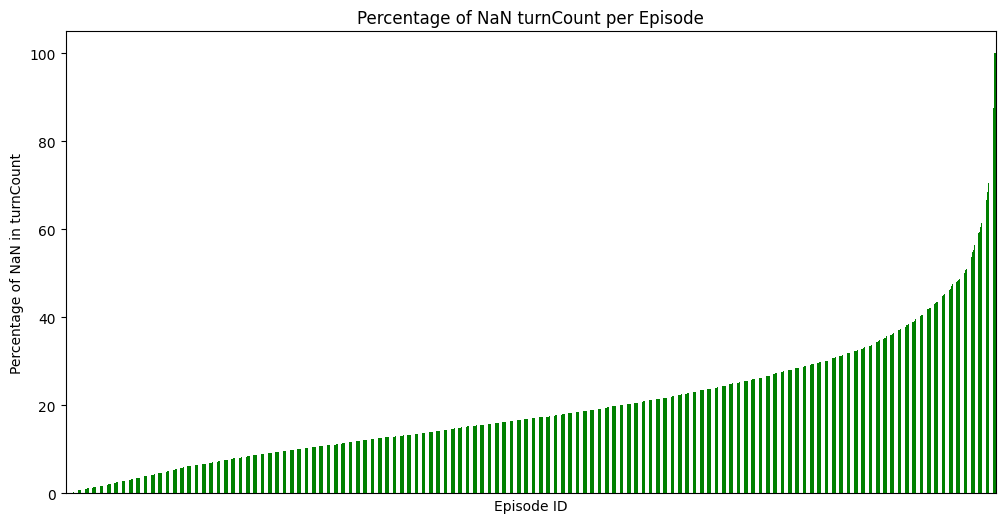

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Group by episode_id and calculate NaN percentage in turnCount
nan_percentages = episodes.groupby('episode_id')['turnCount'].apply(lambda x: x.isna().mean() * 100)

# Plot the results
plt.figure(figsize=(12, 6))
nan_percentages.sort_values().plot(kind='bar', color='green')
plt.xlabel("Episode ID")
plt.ylabel("Percentage of NaN in turnCount")
plt.title("Percentage of NaN turnCount per Episode")
plt.xticks([], [])
plt.show()

### Put paragraphs together 

In [41]:
df = episodes  # Assuming 'episodes' is the input DataFrame

# Initialize an empty list to store processed rows
processed_rows = []

# Loop through each unique episode_id
for episode in df['episode_id'].unique():
    episode_df = df[df['episode_id'] == episode]
    
    # Initialize tracking variables
    concatenated_text = ""
    current_group = []
    racialJustice_1_found = False
    collectiveAction_0_found = False
    collectiveAction_values = []
    
    previous_turnCount = None  # Track turnCount changes

    for _, row in episode_df.iterrows():
        turnCount = row['turnCount']

        # If turnCount changes or it's the first row, process the previous group
        if previous_turnCount is not None and previous_turnCount != turnCount:
            if current_group:
                # Assign computed values to the first row in the group
                current_group[0]['sentence'] = concatenated_text.strip()
                current_group[0]['racialJustice'] = int(racialJustice_1_found)
                current_group[0]['collectiveAction'] = 0 if collectiveAction_0_found else 1
                current_group[0]['collectiveActionMulti'] = (
                    list(set(collectiveAction_values)) if racialJustice_1_found and collectiveAction_0_found else np.nan
                )
                processed_rows.append(current_group[0])  # Save the grouped row

            # Reset variables for new turnCount group
            current_group = []
            concatenated_text = ""
            racialJustice_1_found = False
            collectiveAction_0_found = False
            collectiveAction_values = []

        # Collect sentence text
        concatenated_text += " " + row['sentence']
        
        # Track values for racialJustice and collectiveAction
        if row['racialJustice'] == 1:
            racialJustice_1_found = True
        if row['collectiveAction'] == 0:
            collectiveAction_0_found = True
        if pd.notna(row['collectiveActionMulti']):
            value = row['collectiveActionMulti']
            if isinstance(value, list):
                collectiveAction_values.extend(value)
            else:
                collectiveAction_values.append(value)

        current_group.append(row.to_dict())
        previous_turnCount = turnCount  # Update turn count tracker

    # Ensure the last group is added (including single-row cases)
    if current_group:
        current_group[0]['sentence'] = concatenated_text.strip()
        current_group[0]['racialJustice'] = int(racialJustice_1_found)
        current_group[0]['collectiveAction'] = 0 if collectiveAction_0_found else 1
        current_group[0]['collectiveActionMulti'] = (
            list(set(collectiveAction_values)) if racialJustice_1_found and collectiveAction_0_found else np.nan
        )
        processed_rows.append(current_group[0])

# Convert processed rows into DataFrame
df_processed = pd.DataFrame(processed_rows)

In [42]:
num_none_speakers = df_processed['turnCount'].isna().sum()
percentage_none_speakers = (num_none_speakers / len(df_processed)) * 100
print(f"Number of rows with turnCount = None: {num_none_speakers}")
print(f"Percentage of rows with turnCount = None: {percentage_none_speakers:.2f}%")

Number of rows with turnCount = None: 204573
Percentage of rows with turnCount = None: 62.69%


In [43]:
num_none_speakers = df_processed['newSpeaker'].isna().sum()
percentage_none_speakers = (num_none_speakers / len(df_processed)) * 100
print(f"Number of rows with newSpeaker = None: {num_none_speakers}")
print(f"Percentage of rows with newSpeaker = None: {percentage_none_speakers:.2f}%")

Number of rows with newSpeaker = None: 204579
Percentage of rows with newSpeaker = None: 62.69%


In [44]:
len(df_processed)

326325

In [ ]:
#df_processed.to_csv('../data/paragraph_turns.csv', index=False)

### Put paragraphs together (v2)

In [ ]:
df_processed = pd.read_csv('../data/paragraph_turns.csv')

Assign turnCount to patterns such as n, NaN, NaN, NaN, n+4

In [48]:
def interpolate_turn_count(df):
    # Sort by episode_id and turnCount to ensure correct ordering

    def fill_turn_counts(group):
        turn_counts = group['turnCount'].values
        n = len(turn_counts)

        for i in range(n):
            if np.isnan(turn_counts[i]):  # If we encounter a NaN
                prev_idx = i - 1
                next_idx = i + 1

                # Find the previous non-NaN value
                while prev_idx >= 0 and np.isnan(turn_counts[prev_idx]):
                    prev_idx -= 1
                
                # Find the next non-NaN value
                while next_idx < n and np.isnan(turn_counts[next_idx]):
                    next_idx += 1

                if prev_idx >= 0 and next_idx < n:  # Ensure valid indices
                    prev_value = turn_counts[prev_idx]
                    next_value = turn_counts[next_idx]

                    # Calculate the number of missing values
                    gap = next_idx - prev_idx - 1
                    step_size = next_value - prev_value - 1

                    if gap == step_size:  # Only fill if the gap is valid
                        for j in range(1, gap + 1):
                            turn_counts[prev_idx + j] = prev_value + j

        group['turnCount'] = turn_counts
        return group

    return df.groupby('episode_id', group_keys=False).apply(fill_turn_counts)

# Apply the function
df_fixed = interpolate_turn_count(df_processed)

/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_93232/2784956937.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('episode_id', group_keys=False).apply(fill_turn_counts)


In [49]:
num_none_speakers = df_fixed['turnCount'].isna().sum()
percentage_none_speakers = (num_none_speakers / len(df_processed)) * 100
print(f"Number of rows with turnCount = None: {num_none_speakers}")
print(f"Percentage of rows with turnCount = None: {percentage_none_speakers:.2f}%")

Number of rows with turnCount = None: 149206
Percentage of rows with turnCount = None: 45.72%


In [50]:
num_none_speakers = df_fixed['newSpeaker'].isna().sum()
percentage_none_speakers = (num_none_speakers / len(df_fixed)) * 100
print(f"Number of rows with newSpeaker = None: {num_none_speakers}")
print(f"Percentage of rows with newSpeaker = None: {percentage_none_speakers:.2f}%")

Number of rows with newSpeaker = None: 204579
Percentage of rows with newSpeaker = None: 62.69%


Assign metadata to newly-filled in turncounts

In [51]:
for index, row in df_fixed.iterrows():
    # Check if 'speaker' is NaN and 'turnCount' is not NaN
    if pd.isna(row['speaker']) and not pd.isna(row['turnCount']):
        episode_id = row['episode_id']
        turn_count = row['turnCount']
        
        # Find the corresponding row in the turns df with the same episode_id and turnCount
        matching_row = turns[(turns['episode_id'] == episode_id) & (turns['turnCount'] == turn_count)]
        
        if not matching_row.empty:
            # Update the columns in df_fixed based on the matching row from turns
            df_fixed.at[index, 'speaker'] = matching_row['speaker'].values[0]
            df_fixed.at[index, 'newSpeaker'] = matching_row['newSpeaker'].values[0]
            df_fixed.at[index, 'mfcc1_sma3Mean'] = matching_row['mfcc1_sma3Mean'].values[0]
            df_fixed.at[index, 'mfcc2_sma3Mean'] = matching_row['mfcc2_sma3Mean'].values[0]
            df_fixed.at[index, 'mfcc3_sma3Mean'] = matching_row['mfcc3_sma3Mean'].values[0]
            df_fixed.at[index, 'mfcc4_sma3Mean'] = matching_row['mfcc4_sma3Mean'].values[0]
            df_fixed.at[index, 'F0semitoneFrom27_5Hz_sma3nzMean'] = matching_row['F0semitoneFrom27_5Hz_sma3nzMean'].values[0]
            df_fixed.at[index, 'F1frequency_sma3nzMean'] = matching_row['F1frequency_sma3nzMean'].values[0]
            df_fixed.at[index, 'startTime'] = matching_row['startTime'].values[0]
            df_fixed.at[index, 'endTime'] = matching_row['endTime'].values[0]
            df_fixed.at[index, 'duration'] = matching_row['duration'].values[0]

In [ ]:
#df_fixed.to_csv('../data/paragraph_turns_with_patterns_filled.csv', index=False)

In [ ]:
df_fixed[['speaker','newSpeaker','turnCount','episode_id']].head(20)

Check how many consecutive rows (by index) with the same episode_id and newSpeaker

In [ ]:
df_processed = pd.read_csv('../data/paragraph_turns.csv')
df_fixed = pd.read_csv('../data/paragraph_turns_v2.csv')

In [ ]:
df_fixed[['sentence','speaker']].head()

In [ ]:
df_processed[['sentence','speaker']].head()

In [ ]:
different_rows = df_fixed[df_fixed['speaker'].fillna('MISSING') != df_processed['speaker'].fillna('MISSING')]
different_rows

In [ ]:
df_processed['streak'] = (df_processed[['episode_id', 'speaker']]
                          .ne(df_processed[['episode_id', 'speaker']].shift())
                          .any(axis=1)
                          .cumsum())

df_processed['streak_length'] = df_processed.groupby('streak')['streak'].transform('count')

In [ ]:
df_processed[df_processed['streak_length'] > 1].groupby('streak_length').size()

In [ ]:
total_streaks = df_processed[df_processed['streak_length'] > 1].groupby('streak_length').size().sum()
total_streaks

In [ ]:
df_fixed['streak'] = (df_fixed[['episode_id', 'speaker']]
                          .ne(df_fixed[['episode_id', 'speaker']].shift())
                          .any(axis=1)
                          .cumsum())

df_fixed['streak_length'] = df_fixed.groupby('streak')['streak'].transform('count')

In [ ]:
df_fixed[df_fixed['streak_length'] > 1].groupby('streak_length').size()

In [ ]:
total_streaks = df_fixed[df_fixed['streak_length'] > 1].groupby('streak_length').size().sum()
total_streaks

Concatenate consecutive rows with the same episode_id and newSpeaker

### Load original speaker turns for comparison

In [ ]:
import pandas as pd
episodes = pd.read_csv('../data/paragraph_turns.csv')

In [ ]:
turns = []
num_turns_appended = 0

for episode_id in episodes['episode_id'].unique():
    file_path = f"../data/episodes/speaker_turns/episode_{episode_id}.csv"
    try:
        df_turn = pd.read_csv(file_path)
        df_turn['episode_id'] = episode_id
        turns.append(df_turn)
        num_turns_appended += 1
    except FileNotFoundError:
        continue

turns = pd.concat(turns, ignore_index=True)
print(f"Number of CSV files added to turns: {num_turns_appended}")

In [ ]:
len(turns)

In [ ]:
turns[turns['episode_id'] == 5317][['turnCount','turnText']].tail(20)

In [ ]:
summary_stats = turns['duration'].describe()
print(summary_stats)

### Save some episodes to check quality of paragraph turns

In [ ]:
pd.set_option('display.max_colwidth', None)

In [ ]:
episode_counts = df_fixed['episode_id'].value_counts()
episode_counts.sort_values(ascending=False)

In [ ]:
episode_counts.describe()

Random episodes

In [ ]:
# Filter episode_ids with less than 100 rows
episode_counts = df_fixed['episode_id'].value_counts()
filtered_episode_ids = episode_counts[episode_counts < 100].index

# Pick 5 random episode_ids
random_episode_ids = np.random.choice(filtered_episode_ids, 5, replace=False)
print(random_episode_ids)

In [ ]:
random_ep = df_fixed[df_fixed['episode_id'] == 1989]
len(random_ep)

In [ ]:
from fpdf import FPDF

def save_dataframe_to_pdf(df, filename="output.pdf"):
    pdf = FPDF()
    pdf.set_auto_page_break(auto=True, margin=15)
    pdf.add_page()
    pdf.set_font("Arial", size=12)

    for _, row in df.iterrows():
        # First line: turnCount, duration, speaker, newSpeaker
        pdf.cell(0, 10, f"{row['turnCount']} | {row['duration']} | {row['speaker']} | {row['newSpeaker']}", ln=True)
        # Second line: sentence
        pdf.multi_cell(0, 10, f"{row['sentence']}")
        # Blank line
        pdf.ln(5)
    
    pdf.output(filename)

save_dataframe_to_pdf(random_ep, "../data/episode_paragraph_turns/episode_3004.pdf")

Episodes with a single turn (despite being classified as multi-speaker)

In [ ]:
# Filter episode_ids with less than 100 rows
episode_counts = df_fixed['episode_id'].value_counts()
filtered_episode_ids = episode_counts[episode_counts == 1].index

# Pick 5 random episode_ids
random_episode_ids = np.random.choice(filtered_episode_ids, 5, replace=False)
print(random_episode_ids)

Trying to figure out how many speaker turns there were to begin with

In [ ]:
# turns_episode_shitty = turns[turns['episode_id'] == 2905]
# turns_episode_shitty[['turnText','speaker','newSpeaker']]